# Point 3, Decision Support, Snapshot Adaptive Policy

## Table Of Contents

- [1. The Problem And This Approach](#sec1)
- [2. Data Preparation](#sec2)
- [3. The Cost Model](#sec3)
- [4. The Snapshot Adaptive Policy](#sec4)
- [5. Checking Against Real Outcomes](#sec5)
- [6. Fairness Check](#sec6)
- [7. How Much Would These Numbers Move](#sec7)
- [8. Saving The Standardized Result](#sec8)
- [9. How Sensitive Is This To The Exact Cost Ratio](#sec9)
- [10. Takeaways](#sec10)

<a id="sec1"></a>

## 1. The Problem And This Approach

A memory clinic cannot bring every patient back for a full workup every week, that would be far too expensive, but it also cannot wait years between visits, because a patient can quietly cross from a healthy diagnosis into a worse one between two visits, and nobody notices until the damage is already done. Point 3 turns a risk score, RISK_SCORE below, into an actual scheduling decision, how many months should pass before this patient is checked again.

This notebook is the second of four interval choosing policies covered in this folder. The first, the fixed policy, ignores every patient's own risk and checks everyone on the same schedule, a cheap, fair baseline that the three adaptive policies below have to beat to justify their own added complexity. This one, the snapshot adaptive policy, follows 08-dfl-tf, lesson 1, Predict then Optimize, letting the interval vary row by row with each visit's own current RISK_SCORE, picked from a small menu of candidate intervals to minimize expected cost. It has no memory of a patient's earlier visits, only this one snapshot, the next notebook in this folder, the trajectory adaptive policy, adds that memory back in.

All interval notebooks in this folder, plus the risk factor notebooks, the fairness notebook, and the pipeline notebook that build on the same idea, are self sufficient, each one loads the data, fits or defines its own policy, and appends one standardized row per train and test split to results/decision_support/approach_comparison.csv. A separate notebook, comparison.ipynb, reads that shared file afterward and lines every approach up side by side, so this notebook can be read and rerun entirely on its own.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..', '..'))

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)


<a id="sec2"></a>

## 2. Data Preparation

The cell below loads datasets/final.csv, the single table produced by merging Point 1's imaging derived measures with the clinical and diagnostic fields, one row per patient per visit, keyed by RID and the normalized visit code.

A handful of biomarker columns are not measured at every visit. HIPPO_NORM, ENTORHINAL_NORM, and AMYGDALA_NORM are volumes from Point 1's imaging pipeline, SUMMARY_SUVR and ABETA_RATIO come from the amyloid measurements, TAU and PTAU from the cerebrospinal fluid panel. forward_fill_by_patient carries each patient's most recently known value forward to their later visits, sorted by EXAMDATE_DX, so a visit without a fresh scan can still be scored using the last one that was taken, instead of being dropped outright for missing data.

`RISK_SCORE` now comes from point two's own real discrete time hazard estimator, built in `hazard_survival_model.ipynb`, following 05 pm, lesson 6, directly, structural MRI, amyloid PET, and cerebrospinal fluid together, fit on a genuine multi visit panel rather than one visit predicting only the very next one. That notebook already validates its own chosen estimator on held out patients, area under the ROC curve, a bootstrap confidence interval, and a sanity check against prior diagnosis group, so this notebook only ever reads its saved output, `results/hazard_model/hazard_estimates.csv`, merged in below by `RID` and by visit code.

Coverage is the real cost of that richer estimator. The cerebrospinal fluid markers its own richer feature tier needs are not measured at every visit, so only a bit over half of all rows end up with a genuine `HAZARD_ESTIMATE` this way. The cell below keeps this folder's own earlier fitted estimator too, a Logistic Regression on one hot `DIAGNOSIS` and `AMYLOID_STATUS` categories alone, fit against the same `DIAGNOSIS_WORSENED_NEXT` real outcome `compute_diagnosis_worsening` already provides, now purely as a fallback for whichever rows the richer estimator cannot reach, reported explicitly by coverage percent rather than silently filled in.

Both estimators, the richer one and the fallback, are fit or read only from the training patients below, then applied to every row in both splits, so this stays exactly as independent as before, nothing here reads a column another point in this project produces without that dependency being named directly. Everything downstream of it, the cost model, the policy, the fairness check, still only ever reads the `RISK_SCORE` column by name and does not care how its values were built.

Finally, subject_train_test_split holds out 25 percent of patients, by RID rather than by row, so the same patient's repeated visits never end up split across train and test, with random_state=42 fixed so every approach notebook in this folder, and hazard_survival_model.ipynb itself, trains and tests on exactly the same patients.

In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)

data['DIAGNOSIS_MCI'] = (data['DIAGNOSIS'] == 2).astype(float)
data['DIAGNOSIS_DEMENTIA'] = (data['DIAGNOSIS'] == 3).astype(float)
data['AMYLOID_POSITIVE'] = (data['AMYLOID_STATUS'] == 1).astype(float)
data['AMYLOID_UNKNOWN'] = data['AMYLOID_STATUS'].isna().astype(float)
hazard_features = ['DIAGNOSIS_MCI', 'DIAGNOSIS_DEMENTIA', 'AMYLOID_POSITIVE', 'AMYLOID_UNKNOWN']

train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=42)
train_df = train_df.copy()
test_df = test_df.copy()
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')

fallback_train_outcomes = du.compute_diagnosis_worsening(
    train_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_test_outcomes = du.compute_diagnosis_worsening(
    test_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_train_data = fallback_train_outcomes[fallback_train_outcomes['HAS_NEXT_VISIT']]
fallback_test_data = fallback_test_outcomes[fallback_test_outcomes['HAS_NEXT_VISIT']]

fallback_model, fallback_scaler = du.fit_logistic_baseline(
    fallback_train_data[hazard_features],
    fallback_train_data['DIAGNOSIS_WORSENED_NEXT'],
)
fallback_train_metrics = du.evaluate_classification(
    fallback_model, fallback_train_data[hazard_features], fallback_train_data['DIAGNOSIS_WORSENED_NEXT'], scaler=fallback_scaler,
)
fallback_test_metrics = du.evaluate_classification(
    fallback_model, fallback_test_data[hazard_features], fallback_test_data['DIAGNOSIS_WORSENED_NEXT'], scaler=fallback_scaler,
)
print(f'Fallback estimator, fit on {len(fallback_train_data)} training rows with a next visit on record')
print(f"Fallback estimator, train area under the ROC curve {fallback_train_metrics['auc']:.3f}, "
      f"test area under the ROC curve {fallback_test_metrics['auc']:.3f}")

train_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(train_df[hazard_features]))[:, 1]
test_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(test_df[hazard_features]))[:, 1]

# SWAP POINT: point two now exists, results/hazard_model/hazard_estimates.csv
# holds HAZARD_ESTIMATE from a real multi visit discrete time survival
# model, hazard_survival_model.ipynb, following 05 pm, lesson 6, directly,
# fit on structural MRI, amyloid PET, and cerebrospinal fluid together
# rather than on DIAGNOSIS and AMYLOID_STATUS alone. Coverage is not
# complete, so RISK_SCORE below takes HAZARD_ESTIMATE wherever it exists
# and keeps the fallback estimator above only for the rows it does not
# reach.
hazard_estimates_path = os.path.join('..', '..', '..', 'results', 'hazard_model', 'hazard_estimates.csv')
hazard_estimates = pd.read_csv(hazard_estimates_path)[['RID', 'VISCODE2_norm', 'HAZARD_ESTIMATE']]

train_df = train_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
test_df = test_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')

train_df['RISK_SCORE'] = train_df['HAZARD_ESTIMATE'].fillna(train_df['FALLBACK_RISK_SCORE'])
test_df['RISK_SCORE'] = test_df['HAZARD_ESTIMATE'].fillna(test_df['FALLBACK_RISK_SCORE'])

train_hazard_coverage = train_df['HAZARD_ESTIMATE'].notna().mean() * 100
test_hazard_coverage = test_df['HAZARD_ESTIMATE'].notna().mean() * 100
print(f'Train, {train_hazard_coverage:.1f} percent of rows use the richer survival based HAZARD_ESTIMATE, '
      f'the rest use the fallback estimator above.')
print(f'Test,  {test_hazard_coverage:.1f} percent of rows use the richer survival based HAZARD_ESTIMATE, '
      f'the rest use the fallback estimator above.')

Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients
Fallback estimator, fit on 7280 training rows with a next visit on record
Fallback estimator, train area under the ROC curve 0.694, test area under the ROC curve 0.676
Train, 52.6 percent of rows use the richer survival based HAZARD_ESTIMATE, the rest use the fallback estimator above.
Test,  54.0 percent of rows use the richer survival based HAZARD_ESTIMATE, the rest use the fallback estimator above.


<a id="sec3"></a>

## 3. The Cost Model

Every interval choice trades off two very different kinds of cost. CHECK_COST is what one routine check in visit costs, cheap, and paid every time regardless of what it finds. MISSED_CONVERSION_COST is what it costs to leave a patient unchecked for so long that a phase change is missed entirely and only caught much later, expensive, and only paid when the interval chosen turns out to have been too long for that particular patient. Neither number can be read off ADNI itself, CHECK_COST equal to 1 and a base MISSED_CONVERSION_COST equal to 20 are documented assumptions set once below, so a missed conversion for a patient already Cognitively Normal is treated as worth twenty routine checks, together with REFERENCE_INTERVAL_MONTHS, the interval a cost is measured against, and SAFE_INTERVAL_MONTHS, the fixed policy's own interval that this notebook's menu is compared against.

A single missed conversion cost for every patient hides a real difference. Missing a Cognitively Normal patient's first move toward decline is not the same event as missing a further step down for a patient already diagnosed MCI or Dementia, in the second case there is already more ground to lose and less time to recover it. missed_conversion_cost_for scales the base MISSED_CONVERSION_COST by MCI_OR_WORSE_COST_MULTIPLIER, set to 2.8, for exactly those rows, a Cognitively Normal patient keeps the base cost of 20, an MCI or Dementia patient is priced at 56. The 2.8 figure is not invented for this notebook, a 2026 medRxiv preprint on the societal cost of Alzheimer's disease by diagnosis timing reports roughly 62000 euro per year for an early MCI patient against roughly 175000 euro per year for a late severe Alzheimer's patient, a ratio of about 2.8, used here as the closest available real cost anchor for how much more expensive a later stage missed conversion actually is.

That 2.8 figure is one point estimate from one source, not the only defensible number. A broader targeted literature review, Global Societal Burden of Alzheimer's Disease by Severity, published in Neurology and Therapy and covering 81 separate studies from 2013 to 2024, reports that societal cost typically rises by at least 50 percent between consecutive severity levels, with most studies placing the ratio between mild and severe disease somewhere between about 1.4 and 3.6 depending on which severity scale and which cost scope the underlying study used, and at least one study in the review reporting a fourfold difference. 2.8 sits inside that broader picture rather than at either edge of it, but the picture itself is wide enough that no single number in it should be presented as the settled one. Section 9 below reruns this notebook's own policy at 1.5, at 2.8, and at 4.0, the low end, the default, and the high end actually seen in this literature, so the reader can see directly which conclusions hold across the whole range and which ones depend on the exact multiplier chosen, rather than resting everything on 2.8 alone.

ConversionCostModel follows util.RULCostModel's calling convention from 04-rul, but here the same instantiate once and call .cost as many times pattern is wrapped in cost_model_for, since missed_conversion_cost is now a value that depends on each row's own DIAGNOSIS rather than one fixed number, cost_model_for builds a fresh model scoped to whichever dataframe is passed in, always with rows in the same order the caller will use for rid_ids and risk_scores right after. Every interval policy notebook in this folder uses the same CHECK_COST, base MISSED_CONVERSION_COST, and MCI_OR_WORSE_COST_MULTIPLIER, so a total cost reported here means exactly the same thing as a total cost reported in the other two that price a candidate interval with ConversionCostModel.cost the same way this notebook does. 4_forecast_adaptive.ipynb is a fourth interval policy notebook in this folder sharing these same three constants, but pricing its own policy with ConversionCostModel.cost_from_forecast instead, so its own total_cost is not on this same scale, see comparison.ipynb section 3 for why.

missed_conversion_cost_for and cost_model_for below are now thin, notebook local wrappers around du.stratified_missed_conversion_cost and du.cost_model_for in util/decision_util.py, where the stratification and the citation above actually live once, so a future notebook that needs the same stratified cost only has to import decision_util and call them, not redefine them again.

In [3]:
CHECK_COST = 1.0
MISSED_CONVERSION_COST = 20.0
MCI_OR_WORSE_COST_MULTIPLIER = 2.8
REFERENCE_INTERVAL_MONTHS = 12.0
SAFE_INTERVAL_MONTHS = 6

def missed_conversion_cost_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.stratified_missed_conversion_cost(
        df, MISSED_CONVERSION_COST, multiplier,
    )

def cost_model_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.cost_model_for(
        df, CHECK_COST, MISSED_CONVERSION_COST, multiplier,
        safe_interval_months=SAFE_INTERVAL_MONTHS,
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )


<a id="sec4"></a>

## 4. The Snapshot Adaptive Policy

For each row, recommend_interval chooses the interval from a small menu, 3, 6, or 12 months, that minimizes expected cost under the cost parameters above, using that one visit's own RISK_SCORE and nothing else, not even the same patient's own earlier visits. A high risk visit is priced most cheaply by a short interval, a low risk visit by a long one, the menu search simply tries all three candidates through the cost model's own expected cost math and keeps the cheapest.

There is no model to fit, recommend_interval is a direct calculation from the cost parameters, so evaluate_snapshot_policy below is simply evaluated on train and on test separately, which is still worth doing, checking that the policy's total cost and over threshold count hold up on rows it was not first looked at on is a real check even without any fitting involved. The histogram right after shows how the recommended interval is actually distributed across the two splits, whether most visits land on the short, the middle, or the long end of the menu.

**Why the menu search picks what it picks.** recommend_interval does not fit anything itself, for each candidate interval it computes the same expected cost formula, routine cost plus risk scaled missed conversion cost, and keeps whichever of the three is cheapest, RISK_SCORE is already fixed by the hazard estimator above by the time this menu search runs. Sweeping RISK_SCORE from 0 to 1 and drawing that same formula as a curve, one line per candidate interval, makes the decision visible directly, rather than only inferred from the histogram after the fact. Because missed_conversion_cost_for now prices an MCI or Dementia patient higher than a Cognitively Normal one, the switch itself happens at a different RISK_SCORE for the two groups, so the first two panels below draw the same curves separately for each group rather than mixing them into one. The third panel is where the real test split's own RISK_SCORE actually sits, split into the same two groups and drawn separately from the cost curves rather than sharing an axis with them, a bit over half of the mass in each group now comes from the richer survival based estimator's own continuous spread, the rest still sits at the fallback estimator's own small set of discrete DIAGNOSIS times AMYLOID_STATUS category values. The dotted vertical lines mark where the cheapest candidate interval actually changes for each group, so the same switch is visible against the mechanism on the first two panels and against the real data on the third.

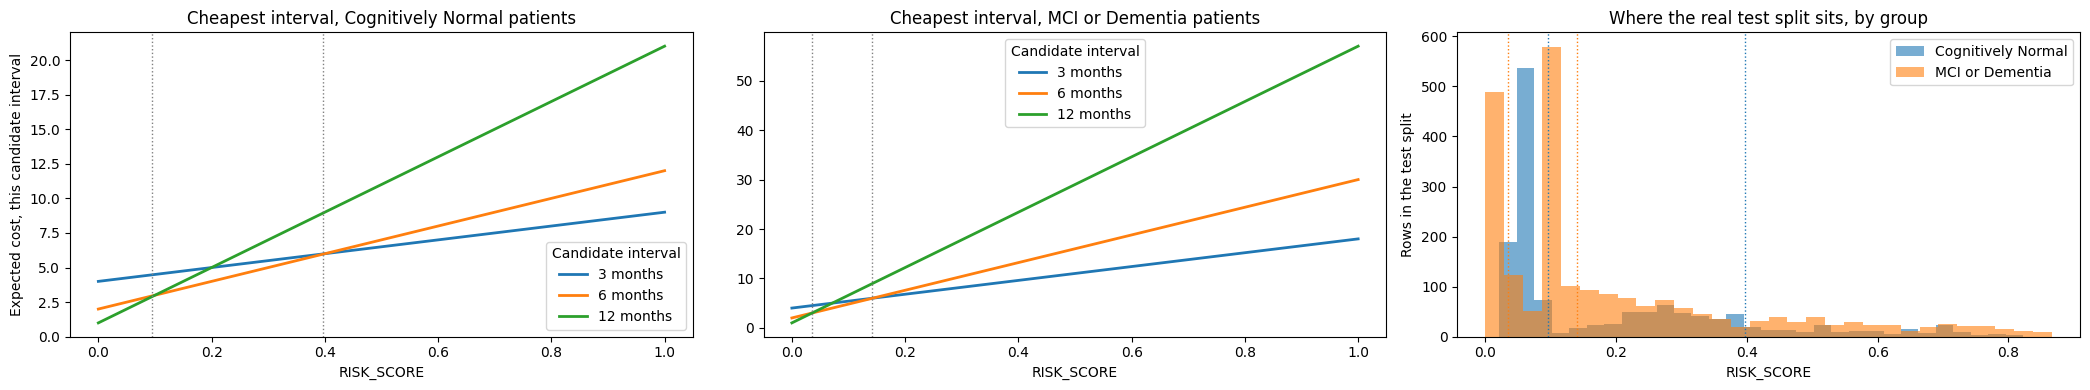

Cognitively Normal patients switch interval at RISK_SCORE = 0.095, 0.397, under the base MISSED_CONVERSION_COST=20.0.
MCI or Dementia patients switch interval at RISK_SCORE = 0.035, 0.141, under the stratified cost 56.0 (base times MCI_OR_WORSE_COST_MULTIPLIER=2.8). The higher cost pulls both switch points down, so an MCI or Dementia patient moves onto a shorter interval at a lower RISK_SCORE than a Cognitively Normal patient would.


In [4]:
def switch_points_for(missed_conversion_cost):
    expected_cost_sweep = {}
    for interval in candidate_menu:
        routine = (12.0 / interval) * CHECK_COST
        scaled_risk = risk_sweep * (interval / REFERENCE_INTERVAL_MONTHS)
        expected_cost_sweep[interval] = routine + scaled_risk * missed_conversion_cost
    best_interval = np.array([
        candidate_menu[i] for i in np.argmin(
            np.stack([expected_cost_sweep[m] for m in candidate_menu]), axis=0,
        )
    ])
    points = risk_sweep[np.where(np.diff(best_interval) != 0)[0]]
    return expected_cost_sweep, points

risk_sweep = np.linspace(0, 1, 200)
candidate_menu = (3, 6, 12)

cn_cost_sweep, cn_switch_points = switch_points_for(MISSED_CONVERSION_COST)
mci_cost_sweep, mci_switch_points = switch_points_for(MISSED_CONVERSION_COST * MCI_OR_WORSE_COST_MULTIPLIER)

fig, axes = plt.subplots(1, 3, figsize=(figsize[0] * 1.5, figsize[1]))

for interval in candidate_menu:
    axes[0].plot(risk_sweep, cn_cost_sweep[interval], label=f'{interval} months', linewidth=2)
for point in cn_switch_points:
    axes[0].axvline(point, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('RISK_SCORE')
axes[0].set_ylabel('Expected cost, this candidate interval')
axes[0].set_title('Cheapest interval, Cognitively Normal patients')
axes[0].legend(title='Candidate interval')

for interval in candidate_menu:
    axes[1].plot(risk_sweep, mci_cost_sweep[interval], label=f'{interval} months', linewidth=2)
for point in mci_switch_points:
    axes[1].axvline(point, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('RISK_SCORE')
axes[1].set_title('Cheapest interval, MCI or Dementia patients')
axes[1].legend(title='Candidate interval')

test_cn = test_df.loc[test_df['DIAGNOSIS'] == 1, 'RISK_SCORE']
test_mci_or_worse = test_df.loc[test_df['DIAGNOSIS'] != 1, 'RISK_SCORE']
axes[2].hist(test_cn, bins=30, alpha=0.6, label='Cognitively Normal')
axes[2].hist(test_mci_or_worse, bins=30, alpha=0.6, label='MCI or Dementia')
for point in cn_switch_points:
    axes[2].axvline(point, color='C0', linestyle=':', linewidth=1)
for point in mci_switch_points:
    axes[2].axvline(point, color='C1', linestyle=':', linewidth=1)
axes[2].set_xlabel('RISK_SCORE')
axes[2].set_ylabel('Rows in the test split')
axes[2].set_title('Where the real test split sits, by group')
axes[2].legend()

plt.tight_layout()
plt.show()

print('Cognitively Normal patients switch interval at RISK_SCORE = '
      + ', '.join(f'{point:.3f}' for point in cn_switch_points)
      + f', under the base MISSED_CONVERSION_COST={MISSED_CONVERSION_COST}.')
print('MCI or Dementia patients switch interval at RISK_SCORE = '
      + ', '.join(f'{point:.3f}' for point in mci_switch_points)
      + f', under the stratified cost {MISSED_CONVERSION_COST * MCI_OR_WORSE_COST_MULTIPLIER:.1f} '
      + f'(base times MCI_OR_WORSE_COST_MULTIPLIER={MCI_OR_WORSE_COST_MULTIPLIER}). The higher cost '
      + 'pulls both switch points down, so an MCI or Dementia patient moves onto a shorter interval '
      + 'at a lower RISK_SCORE than a Cognitively Normal patient would.')

In [5]:
def evaluate_snapshot_policy(df, label):
    recommended = du.recommend_interval(
        df['RISK_SCORE'].values,
        interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST,
        missed_conversion_cost=missed_conversion_cost_for(df),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    total_cost, over_threshold_count, _ = cost_model_for(df).cost(
        rid_ids=df['RID'].values,
        risk_scores=df['RISK_SCORE'].values,
        threshold=0.5,
        interval_months=recommended,
        return_margin=False,
    )
    print(f'{label}, {len(df)} rows')
    print(f'  Snapshot adaptive policy, total cost {total_cost:9.1f}, rows over threshold {over_threshold_count}')
    return recommended, total_cost, over_threshold_count

train_recommended, train_total_cost, train_over_threshold = evaluate_snapshot_policy(train_df, 'Train')
test_recommended, test_total_cost, test_over_threshold = evaluate_snapshot_policy(test_df, 'Test')

train_df = train_df.copy()
test_df = test_df.copy()
train_df['RECOMMENDED_INTERVAL'] = train_recommended
test_df['RECOMMENDED_INTERVAL'] = test_recommended


Train, 10162 rows
  Snapshot adaptive policy, total cost   49504.4, rows over threshold 926
Test, 3665 rows
  Snapshot adaptive policy, total cost   18387.1, rows over threshold 387


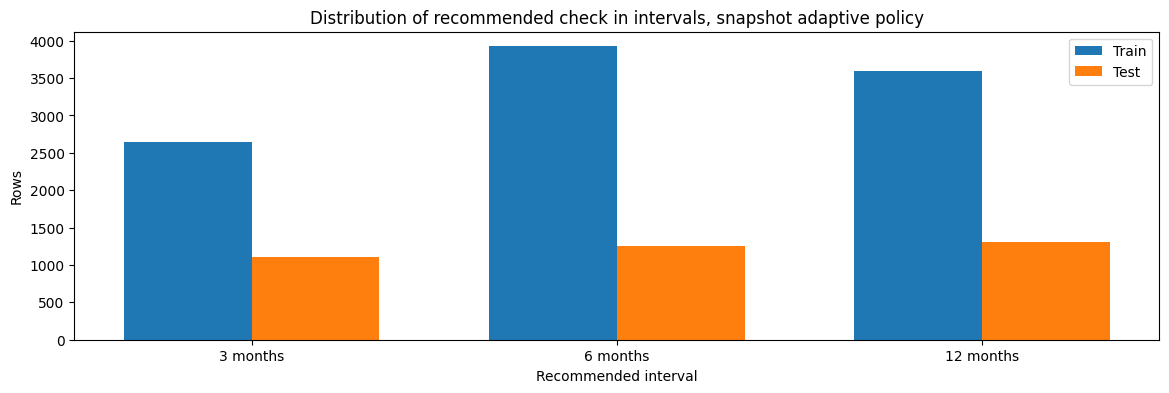

In [6]:
train_counts = pd.Series(train_df['RECOMMENDED_INTERVAL']).value_counts().reindex(candidate_menu, fill_value=0)
test_counts = pd.Series(test_df['RECOMMENDED_INTERVAL']).value_counts().reindex(candidate_menu, fill_value=0)
bar_x = np.arange(len(candidate_menu))
bar_width = 0.35

plt.figure(figsize=figsize)
plt.bar(bar_x - bar_width / 2, train_counts.values, bar_width, label='Train')
plt.bar(bar_x + bar_width / 2, test_counts.values, bar_width, label='Test')
plt.xticks(bar_x, [f'{month} months' for month in candidate_menu])
plt.xlabel('Recommended interval')
plt.ylabel('Rows')
plt.title('Distribution of recommended check in intervals, snapshot adaptive policy')
plt.legend()
plt.show()


<a id="sec5"></a>

## 5. Checking Against Real Outcomes

Every number so far, total cost, the histogram above, is a function of the cost formula and RISK_SCORE alone, nothing yet has checked what actually happened to a real patient outside of the training rows the hazard estimator above already fit on. final.csv already records DIAGNOSIS at every visit, so compute_diagnosis_worsening below finds, for every row, that same patient's next real recorded visit and whether DIAGNOSIS was numerically worse there, a real worsening event, checked here directly against RECOMMENDED_INTERVAL, section 4 above never reads this DIAGNOSIS_WORSENED_NEXT column at all, only RISK_SCORE and the menu it picks from. The hazard estimator that built RISK_SCORE was fit only on training patients, so the check below is a genuinely held out one on the test split, on train the same rows are being checked against an estimator that already saw their own outcome while fitting, exactly why the two splits are read separately below rather than pooled into one number.

For every row with a real worsening event, the margin below is the real gap in months to that next visit minus RECOMMENDED_INTERVAL, this row's own menu choice from section 4. A positive margin means a check on this policy's own schedule would have happened at or before the real worsening was ever observed, caught in time, a negative one means this row's chosen interval would have left the patient unchecked for longer than the real world actually took to reveal it. Unlike the fixed policy, RECOMMENDED_INTERVAL now varies row by row, so the margin below can differ across rows for a reason beyond noise, whether that row's own RISK_SCORE happened to earn it a short or a long interval.

This is retrospective, not a true counterfactual, ADNI's actual visit spacing was never governed by this or any other policy under test here, and it should be read together with the total cost above, not in isolation, since a policy that always recommended the shortest possible interval would trivially win this check alone while being far too expensive to ever deploy.

Train, 501 rows with a real worsening event before the next recorded visit, 84.4 percent would have been caught by this policy in time.
Test, 197 rows with a real worsening event before the next recorded visit, 88.3 percent would have been caught by this policy in time.


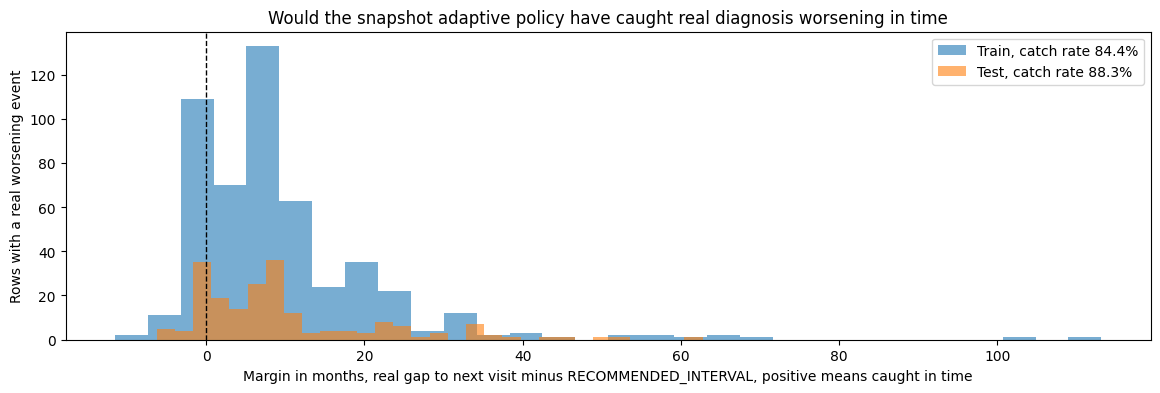

In [7]:
def catch_rate_report(df, label, recommended):
    outcomes = du.compute_diagnosis_worsening(df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    catch_rate = (margin >= 0).mean() * 100
    print(f'{label}, {worsened.sum()} rows with a real worsening event before the next recorded visit, '
          f'{catch_rate:.1f} percent would have been caught by this policy in time.')
    return margin, catch_rate

train_margin, train_catch_rate = catch_rate_report(train_df, 'Train', train_df['RECOMMENDED_INTERVAL'].values)
test_margin, test_catch_rate = catch_rate_report(test_df, 'Test', test_df['RECOMMENDED_INTERVAL'].values)

plt.figure(figsize=figsize)
plt.hist(train_margin, bins=30, alpha=0.6, label=f'Train, catch rate {train_catch_rate:.1f}%')
plt.hist(test_margin, bins=30, alpha=0.6, label=f'Test, catch rate {test_catch_rate:.1f}%')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Margin in months, real gap to next visit minus RECOMMENDED_INTERVAL, positive means caught in time')
plt.ylabel('Rows with a real worsening event')
plt.title('Would the snapshot adaptive policy have caught real diagnosis worsening in time')
plt.legend()
plt.show()

<a id="sec6"></a>

## 6. Fairness Check

DIDI, the Disparate Impact Discrimination Index from 07-ciml, lesson 1, measures how much a recommendation differs on average between a protected group and the rest, summed over every protected attribute checked, here PTGENDER, a bucketed PTEDUCAT, and PTMARRY. Unlike the fixed policy, the recommendation here actually varies row by row, since it reads each row's own RISK_SCORE, so DIDI is not guaranteed to be 0 anymore, if the groups checked have different average risk, the snapshot adaptive policy is free to recommend different average intervals for them, and DIDI is exactly what catches that.

In [8]:
def make_protected(df):
    return {
        'PTGENDER': (1, 2),
        'PTEDUCAT_BUCKET': (0, 1),
        'PTMARRY': tuple(sorted(df['PTMARRY'].dropna().unique())),
    }

train_df = train_df.copy()
test_df = test_df.copy()
train_df['PTEDUCAT_BUCKET'] = du.bucket_educat(train_df['PTEDUCAT'], split_at=16)
test_df['PTEDUCAT_BUCKET'] = du.bucket_educat(test_df['PTEDUCAT'], split_at=16)

train_didi = du.compute_didi(train_df, train_df['RECOMMENDED_INTERVAL'].values, make_protected(train_df))
test_didi = du.compute_didi(test_df, test_df['RECOMMENDED_INTERVAL'].values, make_protected(test_df))
print(f'DIDI on the recommended interval, train: {train_didi:.3f}')
print(f'DIDI on the recommended interval, test:  {test_didi:.3f}')


DIDI on the recommended interval, train: 5.948
DIDI on the recommended interval, test:  7.200


<a id="sec7"></a>

## 7. How Much Would These Numbers Move

Every number above, total cost, DIDI, catch rate, comes from one fixed sample of patients, the actual train and test split. A different, equally valid sample of ADNI patients would give a slightly different number, bootstrap_ci below answers by how much, resample patients with replacement 400 times, a patient's own full set of rows moves together since two visits from one patient are not two independent draws, recompute the same metric on each resample, and read the 2.5th and 97.5th percentile as a 95 percent interval. The histograms below are the full bootstrap distribution behind each interval, not only its two endpoints.

Wide or narrow, this interval says nothing about whether the number is good, only how much of it is signal against a different sample versus noise from this particular one, useful together with the comparison against the other three policies, not instead of it.

Train, total cost 49504.4, 95% CI [47313.2, 51775.3]
Test,  total cost 18387.1, 95% CI [16912.9, 19886.2]
Train, catch rate 84.4%, 95% CI [81.2, 87.6]
Test,  catch rate 88.3%, 95% CI [83.9, 92.8]


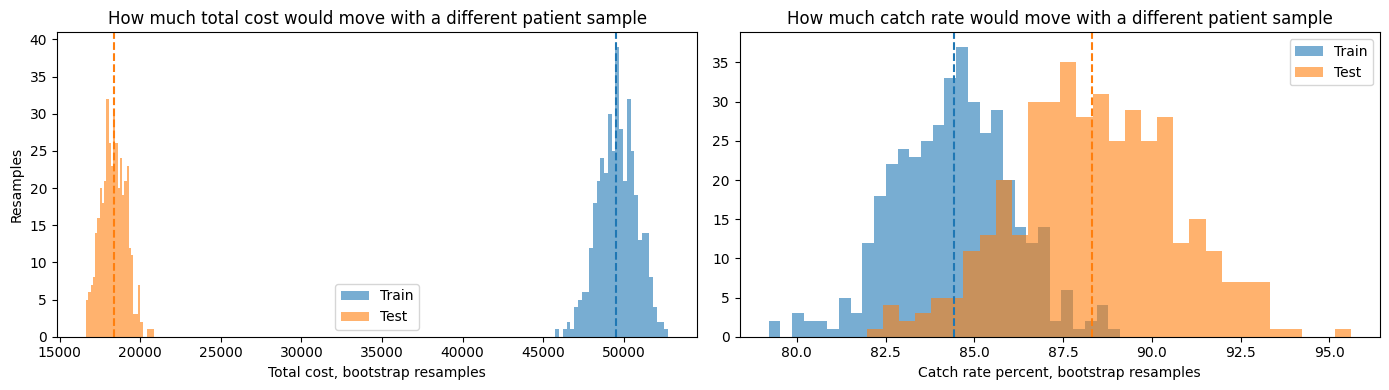

In [9]:
def cost_metric(d):
    recommended = du.recommend_interval(
        d['RISK_SCORE'].values, interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(d),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    total_cost, _, _ = cost_model_for(d).cost(
        rid_ids=d['RID'].values, risk_scores=d['RISK_SCORE'].values,
        threshold=0.5, interval_months=recommended, return_margin=False,
    )
    return total_cost

def didi_metric(d):
    d = d.copy()
    d['PTEDUCAT_BUCKET'] = du.bucket_educat(d['PTEDUCAT'], split_at=16)
    recommended = du.recommend_interval(
        d['RISK_SCORE'].values, interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(d),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    return du.compute_didi(d, recommended, make_protected(d))

def catch_rate_metric(d):
    recommended = du.recommend_interval(
        d['RISK_SCORE'].values, interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(d),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    outcomes = du.compute_diagnosis_worsening(d, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    return (margin >= 0).mean() * 100

train_cost_point, train_cost_lo, train_cost_hi, train_cost_samples = du.bootstrap_ci(train_df, cost_metric, id_col='RID')
test_cost_point, test_cost_lo, test_cost_hi, test_cost_samples = du.bootstrap_ci(test_df, cost_metric, id_col='RID')
train_didi_point, train_didi_lo, train_didi_hi, _ = du.bootstrap_ci(train_df, didi_metric, id_col='RID')
test_didi_point, test_didi_lo, test_didi_hi, _ = du.bootstrap_ci(test_df, didi_metric, id_col='RID')
train_catch_point, train_catch_lo, train_catch_hi, train_catch_samples = du.bootstrap_ci(train_df, catch_rate_metric, id_col='RID')
test_catch_point, test_catch_lo, test_catch_hi, test_catch_samples = du.bootstrap_ci(test_df, catch_rate_metric, id_col='RID')

print(f'Train, total cost {train_cost_point:.1f}, 95% CI [{train_cost_lo:.1f}, {train_cost_hi:.1f}]')
print(f'Test,  total cost {test_cost_point:.1f}, 95% CI [{test_cost_lo:.1f}, {test_cost_hi:.1f}]')
print(f'Train, catch rate {train_catch_point:.1f}%, 95% CI [{train_catch_lo:.1f}, {train_catch_hi:.1f}]')
print(f'Test,  catch rate {test_catch_point:.1f}%, 95% CI [{test_catch_lo:.1f}, {test_catch_hi:.1f}]')

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(train_cost_samples, bins=30, alpha=0.6, label='Train')
axes[0].hist(test_cost_samples, bins=30, alpha=0.6, label='Test')
axes[0].axvline(train_cost_point, color='C0', linestyle='--')
axes[0].axvline(test_cost_point, color='C1', linestyle='--')
axes[0].set_xlabel('Total cost, bootstrap resamples')
axes[0].set_ylabel('Resamples')
axes[0].set_title('How much total cost would move with a different patient sample')
axes[0].legend()

axes[1].hist(train_catch_samples, bins=30, alpha=0.6, label='Train')
axes[1].hist(test_catch_samples, bins=30, alpha=0.6, label='Test')
axes[1].axvline(train_catch_point, color='C0', linestyle='--')
axes[1].axvline(test_catch_point, color='C1', linestyle='--')
axes[1].set_xlabel('Catch rate percent, bootstrap resamples')
axes[1].set_title('How much catch rate would move with a different patient sample')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="sec8"></a>

## 8. Saving The Standardized Result

One row per split, appended to the shared results/decision_support/approach_comparison.csv, read later by comparison.ipynb alongside the other approaches. append_approach_result is idempotent per approach and split, rerunning this notebook replaces its own two rows rather than piling up duplicates. The confidence intervals from the section above ride along in the same row.

In [10]:
du.append_approach_result(
    results_path, approach='snapshot_adaptive', approach_group='interval_policy',
    split='train', n_rows=len(train_df), total_cost=train_total_cost,
    over_threshold_count=train_over_threshold, didi=train_didi,
    catch_rate=train_catch_rate,
    ci={
        'total_cost': (train_cost_lo, train_cost_hi),
        'didi': (train_didi_lo, train_didi_hi),
        'catch_rate': (train_catch_lo, train_catch_hi),
    },
    notes='Predict then Optimize on the current visit RISK_SCORE only, menu 3, 6, 12 months.',
)
result_row = du.append_approach_result(
    results_path, approach='snapshot_adaptive', approach_group='interval_policy',
    split='test', n_rows=len(test_df), total_cost=test_total_cost,
    over_threshold_count=test_over_threshold, didi=test_didi,
    catch_rate=test_catch_rate,
    ci={
        'total_cost': (test_cost_lo, test_cost_hi),
        'didi': (test_didi_lo, test_didi_hi),
        'catch_rate': (test_catch_lo, test_catch_hi),
    },
    notes='Predict then Optimize on the current visit RISK_SCORE only, menu 3, 6, 12 months.',
)
result_row

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
0,unconstrained,fairness_correction,train,2048,NaN,NaN,0.084095,NaN,0.344772,0.175168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
1,unconstrained,fairness_correction,test,753,NaN,NaN,0.128358,NaN,0.056403,0.211343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
2,fixed_lambda,fairness_correction,train,2048,NaN,NaN,0.029024,NaN,-0.046617,0.212322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
3,fixed_lambda,fairness_correction,test,753,NaN,NaN,0.048055,NaN,-0.290264,0.232721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
4,dual_lambda,fairness_correction,train,2048,NaN,NaN,0.042104,NaN,0.336206,0.177150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
5,dual_lambda,fairness_correction,test,753,NaN,NaN,0.122326,NaN,0.067258,0.210892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
6,pipeline_health_index,interval_policy,train,10162,59644.077200,4837.0,2.930656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
7,pipeline_health_index,interval_policy,test,3665,21640.887371,1752.0,2.029942,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
8,hazard_logistic_core,hazard_model,train,6415,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Discrete time hazard estimator, logistic, core..."
9,hazard_logistic_core,hazard_model,test,2291,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.704754,0.782472,"Discrete time hazard estimator, logistic, core..."


<a id="sec9"></a>

## 9. How Sensitive Is This To The Exact Cost Ratio

Section 3 already flagged that MCI_OR_WORSE_COST_MULTIPLIER, set to 2.8, is a single point estimate sitting inside a documented range that runs from about 1.4 to about 4 depending on the study. Unlike the fixed policy, this notebook's own menu search uses that multiplier directly to decide which interval a given patient gets, section 4's own switch point plot already shows the MCI or Dementia switch points moving left as the stratified cost rises, so a different multiplier can change RECOMMENDED_INTERVAL itself, not only how expensive the outcome looks afterward.

The cell below reruns evaluate_snapshot_policy's own menu search at 1.5, at 2.8, and at 4.0, holding every other setting fixed, and reports total_cost and catch_rate at each one, on both splits, saved to cost_sensitivity_snapshot_adaptive.csv for comparison.ipynb to read alongside the other three policies.

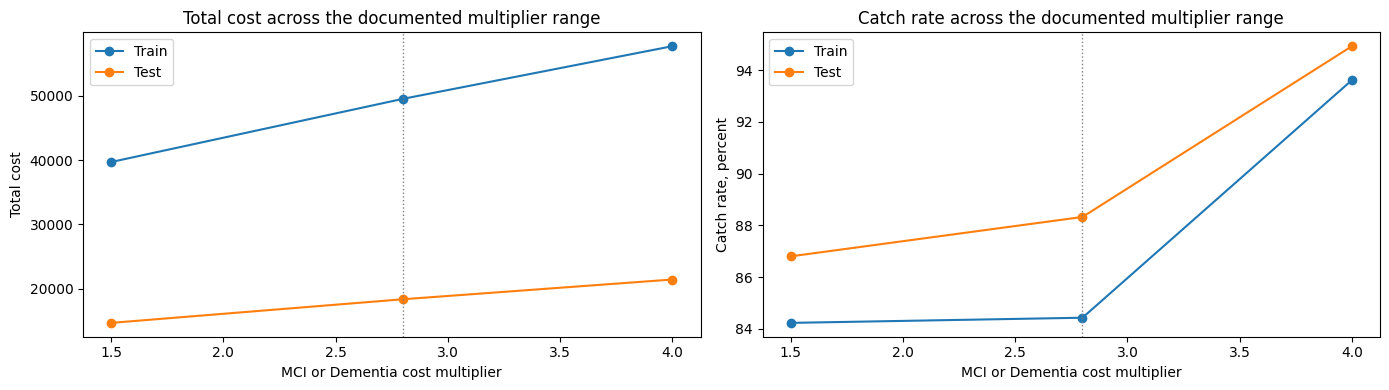

,multiplier,approach,train_total_cost,test_total_cost,train_catch_rate,test_catch_rate
0,1.5,snapshot_adaptive,39690.845347,14717.156236,84.231537,86.802030
1,2.8,snapshot_adaptive,49504.449871,18387.063297,84.431138,88.324873
2,4.0,snapshot_adaptive,57680.113039,21451.182782,93.612774,94.923858


In [11]:
SENSITIVITY_MULTIPLIERS = (1.5, 2.8, 4.0)

def sensitivity_at(df, multiplier):
    recommended = du.recommend_interval(
        df['RISK_SCORE'].values,
        interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST,
        missed_conversion_cost=missed_conversion_cost_for(df, multiplier=multiplier),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    total_cost, _, _ = cost_model_for(df, multiplier=multiplier).cost(
        rid_ids=df['RID'].values,
        risk_scores=df['RISK_SCORE'].values,
        threshold=0.5,
        interval_months=recommended,
        return_margin=False,
    )
    outcomes = du.compute_diagnosis_worsening(df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    catch_rate = (margin >= 0).mean() * 100
    return total_cost, catch_rate

sensitivity_rows = []
for multiplier in SENSITIVITY_MULTIPLIERS:
    train_cost, train_catch = sensitivity_at(train_df, multiplier)
    test_cost, test_catch = sensitivity_at(test_df, multiplier)
    sensitivity_rows.append({
        'multiplier': multiplier,
        'approach': 'snapshot_adaptive',
        'train_total_cost': train_cost,
        'test_total_cost': test_cost,
        'train_catch_rate': train_catch,
        'test_catch_rate': test_catch,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(os.path.join(results_path, 'cost_sensitivity_snapshot_adaptive.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=figsize)
axes[0].plot(sensitivity_df['multiplier'], sensitivity_df['train_total_cost'], marker='o', label='Train')
axes[0].plot(sensitivity_df['multiplier'], sensitivity_df['test_total_cost'], marker='o', label='Test')
axes[0].axvline(MCI_OR_WORSE_COST_MULTIPLIER, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('MCI or Dementia cost multiplier')
axes[0].set_ylabel('Total cost')
axes[0].set_title('Total cost across the documented multiplier range')
axes[0].legend()

axes[1].plot(sensitivity_df['multiplier'], sensitivity_df['train_catch_rate'], marker='o', label='Train')
axes[1].plot(sensitivity_df['multiplier'], sensitivity_df['test_catch_rate'], marker='o', label='Test')
axes[1].axvline(MCI_OR_WORSE_COST_MULTIPLIER, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('MCI or Dementia cost multiplier')
axes[1].set_ylabel('Catch rate, percent')
axes[1].set_title('Catch rate across the documented multiplier range')
axes[1].legend()

plt.tight_layout()
plt.show()

sensitivity_df

<a id="sec10"></a>

## 10. Takeaways

**Read this notebook's own numbers above as this approach's result on its own.** Uses more information than the fixed policy, this visit's own RISK_SCORE, but still none of the patient's earlier visits, unlike the trajectory adaptive policy next. See comparison.ipynb for how it stacks up against the other three interval policies, that side by side comparison is deliberately kept out of this notebook so it stays correct even if this notebook is rerun on its own later, with different cost parameters or a different biomarker set.